In [1]:
import pandas as pd

# Load dataset
data = pd.read_csv("plants.csv")

print("🌱 AI Indoor Plant Advisor 🌱")

# User input
plant_name = input("What plant do you want to grow? ").lower()
room_sunlight = input("Room sunlight (low / medium / high): ").lower()
room_space = input("Room space (small / medium / large): ").lower()

# Find plant
plant = data[data["plant"].str.lower() == plant_name]

if plant.empty:
    print("\n⚠ Plant not found in dataset.")
    print("General advice:")
    print("- Place the plant near natural light")
    print("- Water moderately")
    print("- Check plant requirements online")

else:
    plant_sun = plant.iloc[0]["sunlight"]
    plant_space = plant.iloc[0]["space"]
    plant_water = plant.iloc[0]["water"]
    plant_location = plant.iloc[0]["location"]

    score = 0

    # Sunlight analysis
    if plant_sun == room_sunlight:
        score += 5
    elif plant_sun == "high" and room_sunlight == "medium":
        score += 3
    else:
        score += 1

    # Space analysis
    if plant_space == room_space:
        score += 5
    elif plant_space == "medium" and room_space == "large":
        score += 4
    else:
        score += 2

    print("\n🌿 Plant:", plant_name.title())
    print("Recommended location:", plant_location)
    print("Watering:", plant_water)
    print("Compatibility score:", score, "/10")

    if score >= 8:
        print("✅ Great choice for your room!")
    elif score >= 5:
        print("👍 Possible to grow with care.")
    else:
        print("⚠ Not ideal for your room.")

# Recommend plants for the room
print("\n🌿 Plants suitable for your room:")

recommend = data[
    (data["sunlight"] == room_sunlight) &
    (data["space"] == room_space)
]

if recommend.empty:
    print("No exact match found.")
else:
    for p in recommend["plant"]:
        print("-", p.title())

🌱 AI Indoor Plant Advisor 🌱


What plant do you want to grow?  tomato
Room sunlight (low / medium / high):  medium
Room space (small / medium / large):  small



🌿 Plant: Tomato
Recommended location: balcony
Watering: daily
Compatibility score: 5 /10
👍 Possible to grow with care.

🌿 Plants suitable for your room:
- Mint
- Coriander
- Green Onion
- Lettuce
- Pak Choi
- Spinach
- Spider Plant
- Money Plant
- Orchid
- Anthurium
- Chrysanthemum
- Begonia
- Parsley


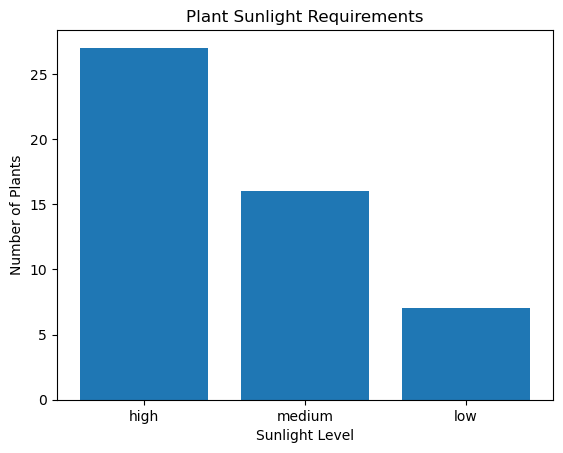

In [2]:
import matplotlib.pyplot as plt
sun_counts = data["sunlight"].value_counts()

plt.bar(sun_counts.index, sun_counts.values)
plt.title("Plant Sunlight Requirements")
plt.xlabel("Sunlight Level")
plt.ylabel("Number of Plants")
plt.show()

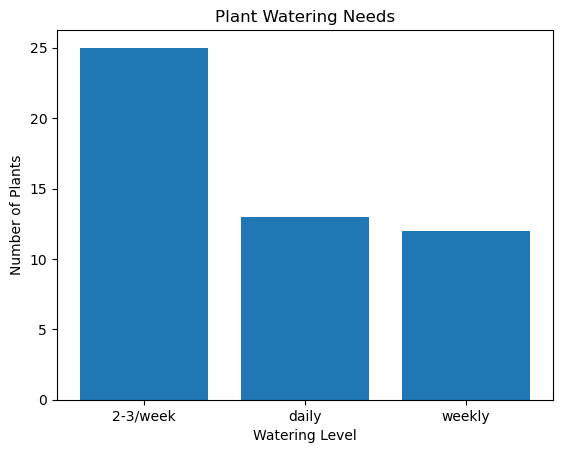

In [3]:
import matplotlib.pyplot as plt

water_counts = data["water"].value_counts()

plt.bar(water_counts.index, water_counts.values)
plt.title("Plant Watering Needs")
plt.xlabel("Watering Level")
plt.ylabel("Number of Plants")
plt.show()

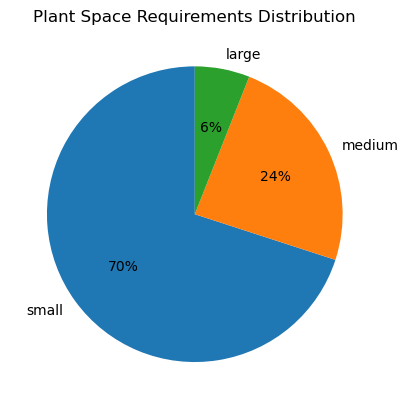

In [4]:
import matplotlib.pyplot as plt


space_counts = data["space"].value_counts()

plt.pie(
    space_counts.values,
    labels=space_counts.index,
    autopct='%1.0f%%',
    startangle=90
)

plt.title("Plant Space Requirements Distribution")

plt.show()